In [1]:
project_desc = """
Weather Pattern Analysis & Prediction System

| Objective:
Analyze and model historical weather data to:
- Understand temperature, humidity, wind speed, and pressure trends
- Explore seasonal and hourly weather patterns
- Identify key correlations between weather parameters
- Build a predictive model for short-term weather forecasting

| Prediction Goal:
Develop a machine learning model that predicts temperature, humidity, and wind speed for the upcoming hours/days based on historical data. The model will help in:
- Weather forecasting for urban planning
- Supporting smart city initiatives
- Assisting sectors like agriculture, logistics, and transportation

| Flask App:
The Flask web application serves as an interactive platform to:
- Provide an interactive Leaflet map with search and marker placement
- On marker click, use the OpenWeather API to fetch current weather data for that location
- Load the trained prediction model to forecast temperature and compare predictions with real-time data side-by-side
- Offer a user-friendly interface for exploring weather patterns and forecasts

Dataset: https://www.kaggle.com/datasets/muthuj7/weather-dataset/data
(Kaggle)
"""

print(project_desc)


Weather Pattern Analysis & Prediction System

| Objective:
Analyze and model historical weather data to:
- Understand temperature, humidity, wind speed, and pressure trends
- Explore seasonal and hourly weather patterns
- Identify key correlations between weather parameters
- Build a predictive model for short-term weather forecasting

| Prediction Goal:
Develop a machine learning model that predicts temperature, humidity, and wind speed for the upcoming hours/days based on historical data. The model will help in:
- Weather forecasting for urban planning
- Supporting smart city initiatives
- Assisting sectors like agriculture, logistics, and transportation

| Flask App:
The Flask web application serves as an interactive platform to:
- Provide an interactive Leaflet map with search and marker placement
- On marker click, use the OpenWeather API to fetch current weather data for that location
- Load the trained prediction model to forecast temperature and compare predictions with real-t

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("./datasets/weatherHistory.csv")

# Information about dataset
print(df.head())
print(df.info())
print(df.describe())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [3]:
# Data Cleaning
old_rows_count = df.shape[0]

#  Droping duplicated rows
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

# Handle missing values only in Precip Type
print("Missing values before:", df.isna().sum())

df['Precip Type'] = df['Precip Type'].fillna('rain')  # filling with common
print("Missing values after:", df.isna().sum())

# Reset index
df = df.reset_index(drop=True)

print("Removed rows:", old_rows_count - df.shape[0])
df.head()

Duplicates after: 0
Missing values before: Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64
Missing values after: Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64
Removed rows: 24


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
# Feature Engineering

# Date & Time
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True, errors='coerce')

df['Date'] = df['Formatted Date'].dt.date
df['Hour'] = df['Formatted Date'].dt.hour

# Encode categorical 
df['Precip Type'] = df['Precip Type'].map({'rain': 0, 'snow': 1})

# Temperature difference 
df['Temp_Diff'] = df['Apparent Temperature (C)'] - df['Temperature (C)']

# Wind speed 
df['Wind_Category'] = pd.cut(
    df['Wind Speed (km/h)'],
    bins=[-1, 5, 15, 100],
    labels=['Low', 'Medium', 'High']
)

# Encoding Wind Category
df['Wind_Category'] = df['Wind_Category'].map({'Low': 0, 'Medium': 1, 'High': 2})

print("Current columns:", df.columns.tolist())
df.head()

Current columns: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary', 'Date', 'Hour', 'Temp_Diff', 'Wind_Category']


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Date,Hour,Temp_Diff,Wind_Category
0,2006-03-31 22:00:00+00:00,Partly Cloudy,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-03-31,22,-2.083333,1
1,2006-03-31 23:00:00+00:00,Partly Cloudy,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-03-31,23,-2.127778,1
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01,0,0.000000,0
3,2006-04-01 01:00:00+00:00,Partly Cloudy,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01,1,-2.344444,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01,2,-1.777778,1


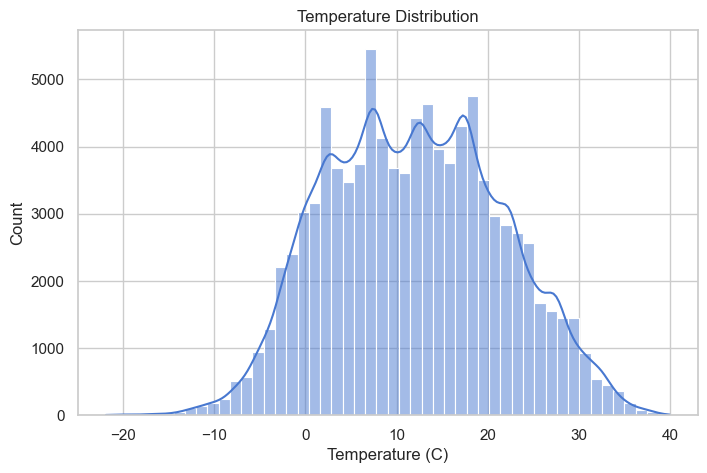

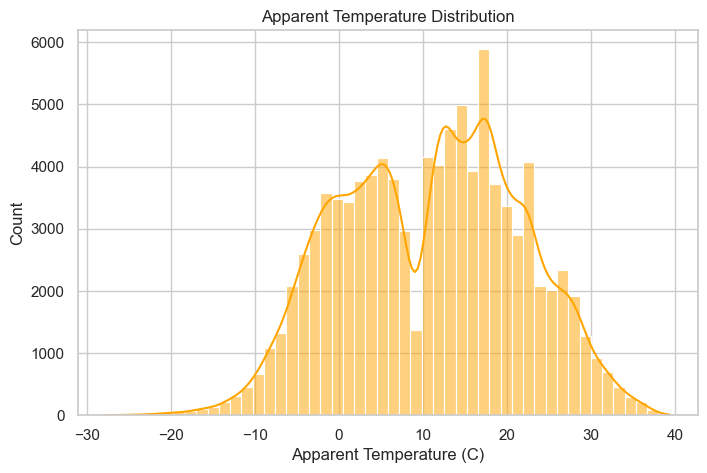

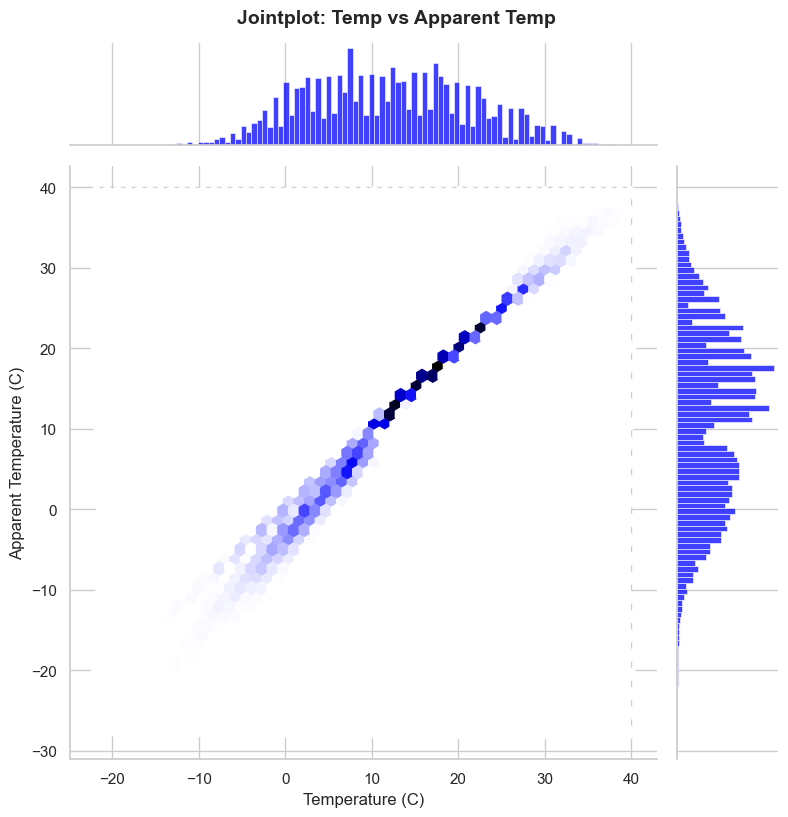

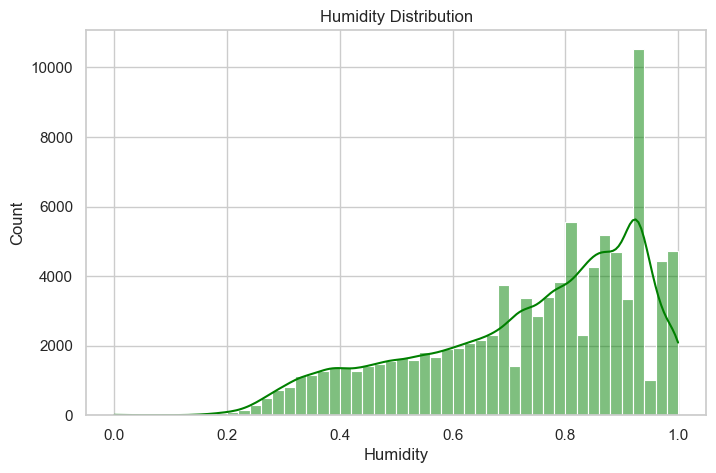

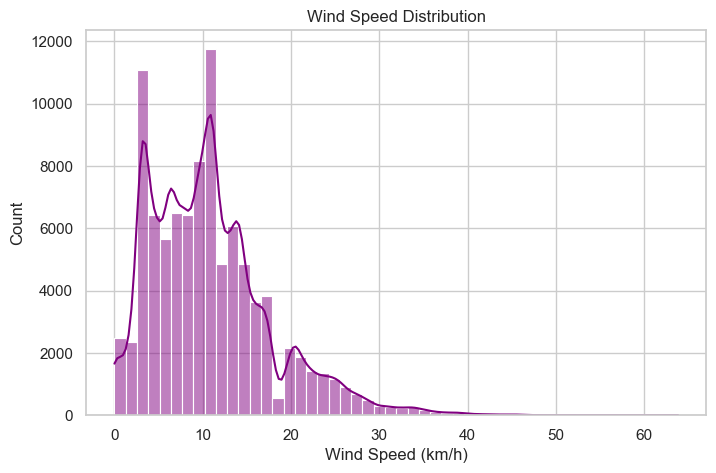

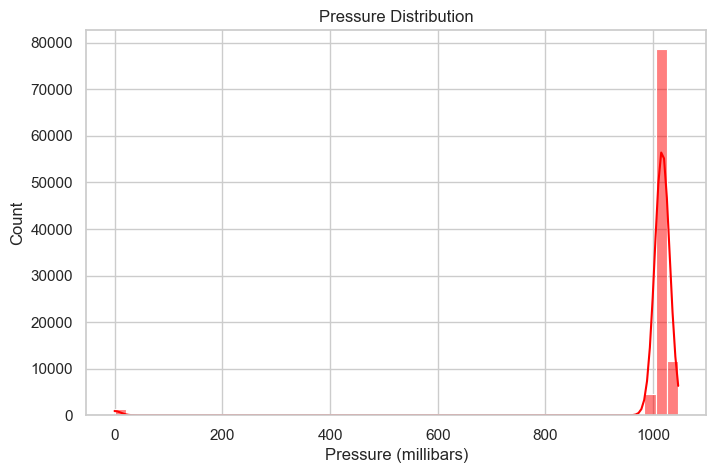

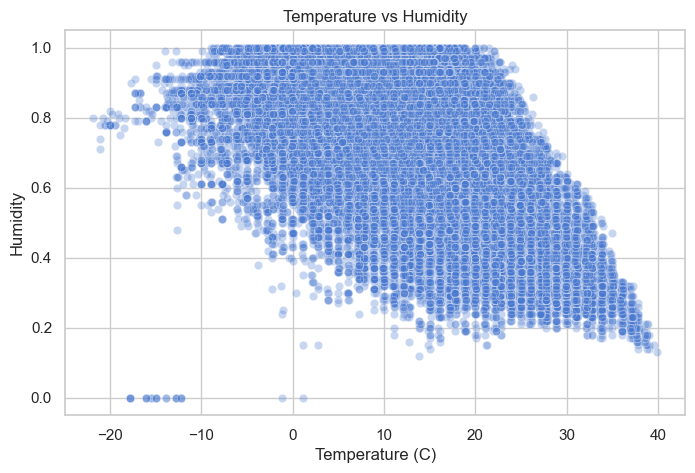

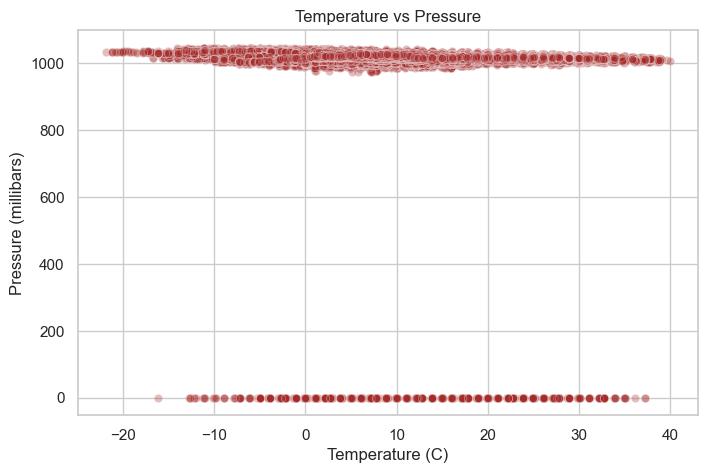

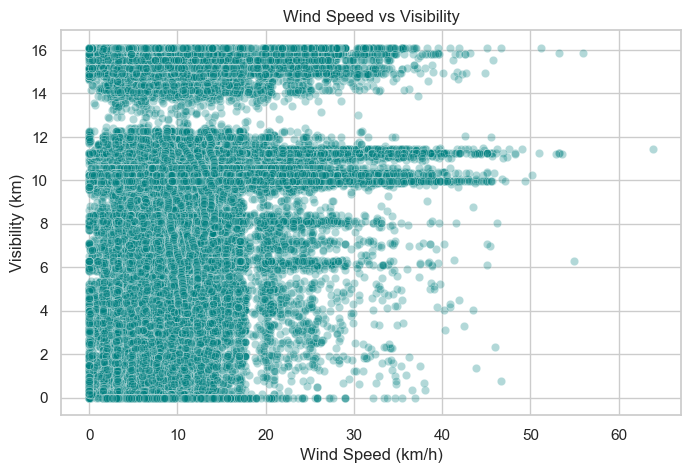

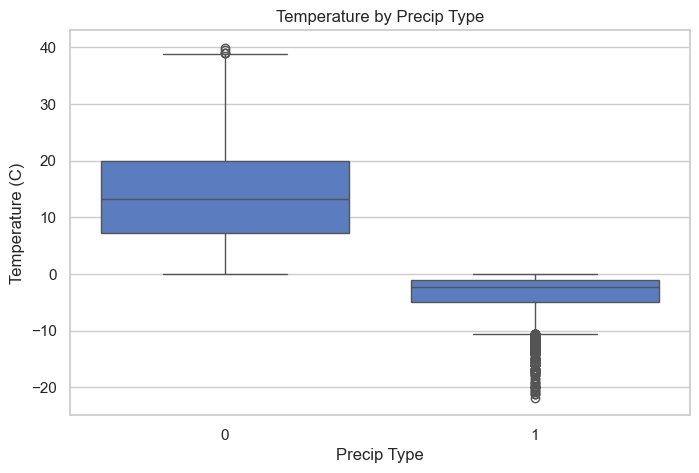

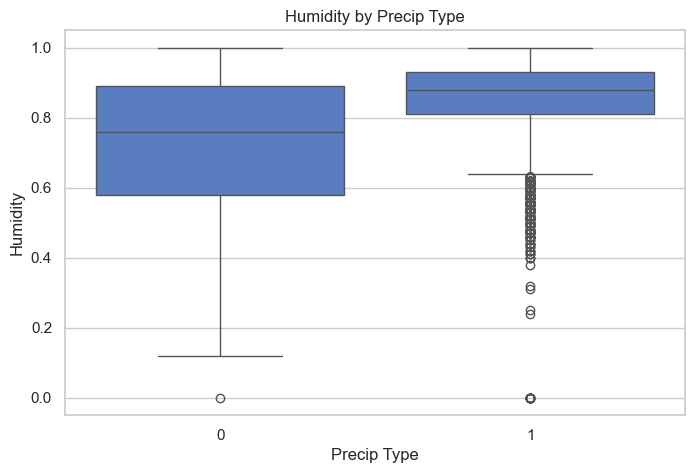

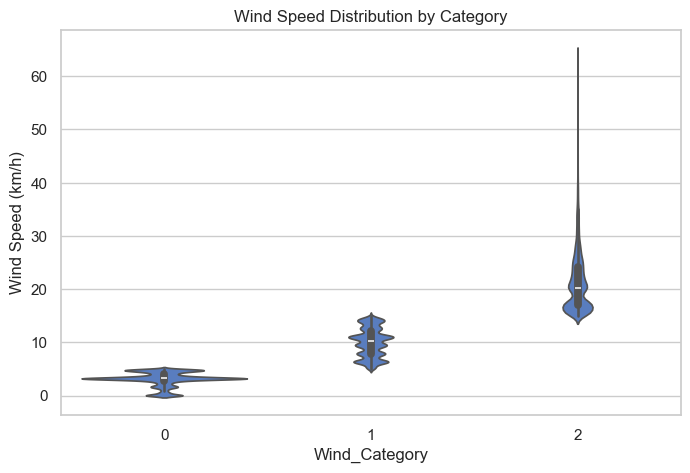

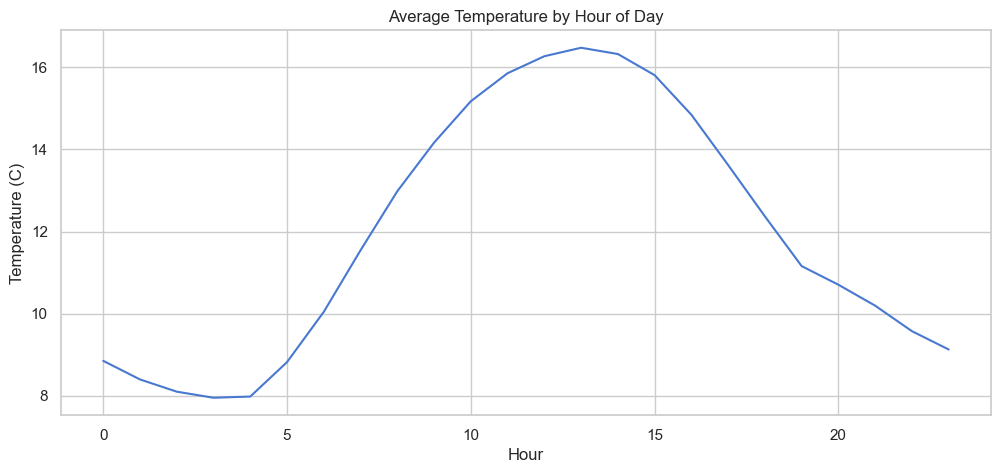

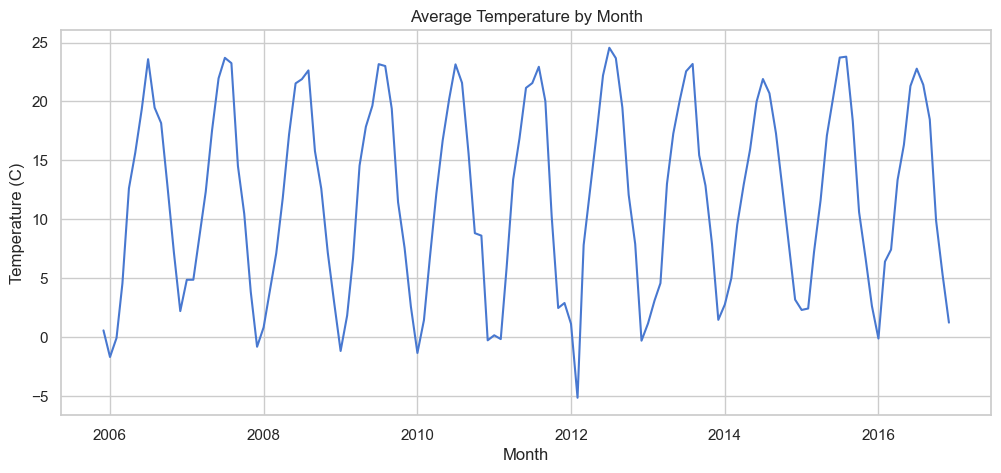

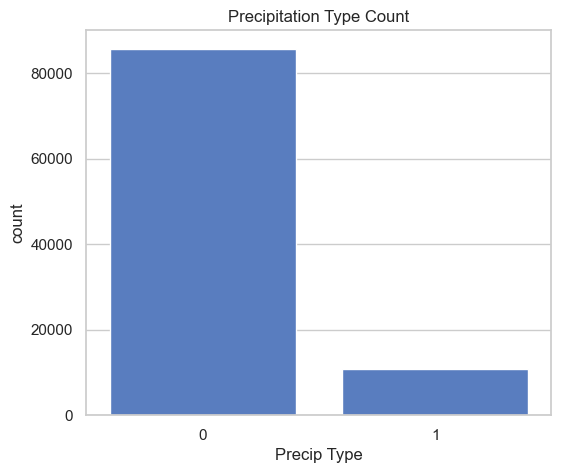

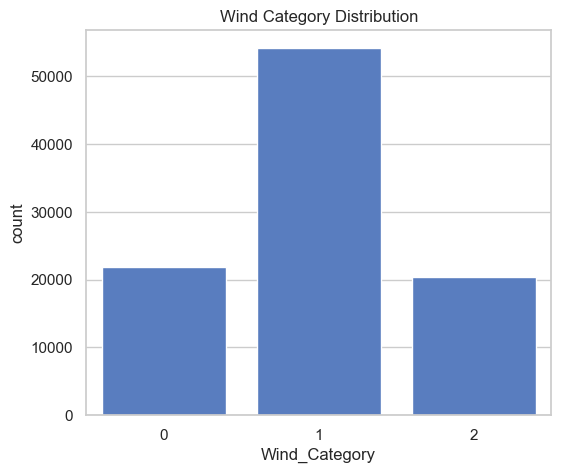

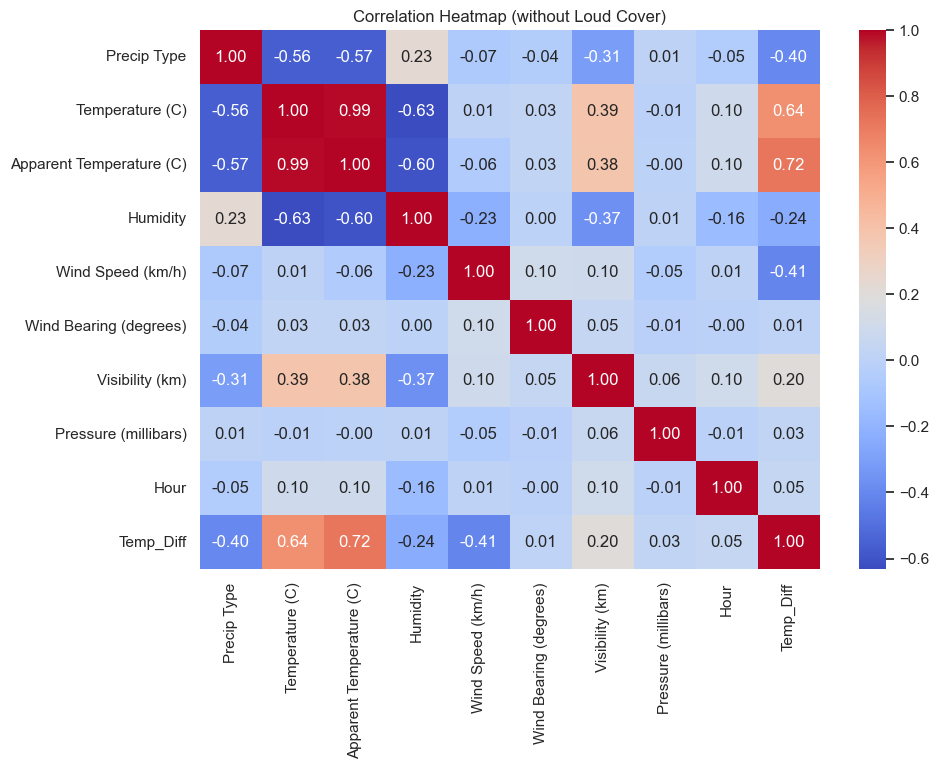

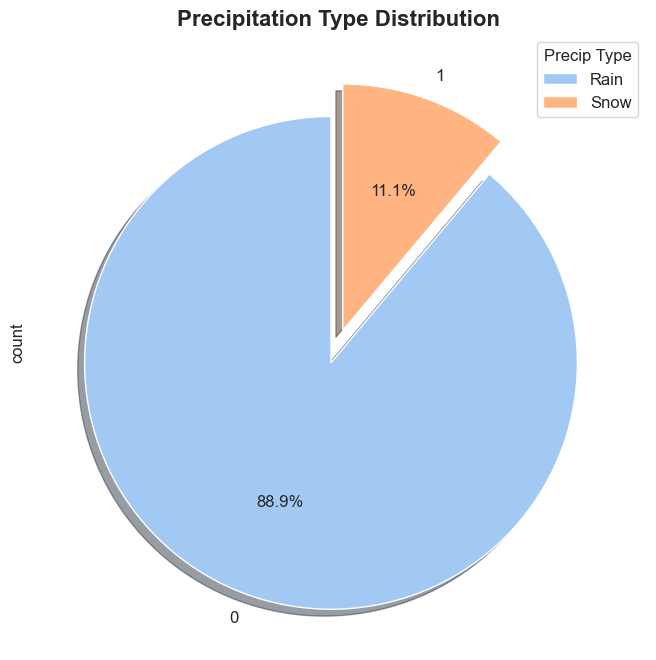

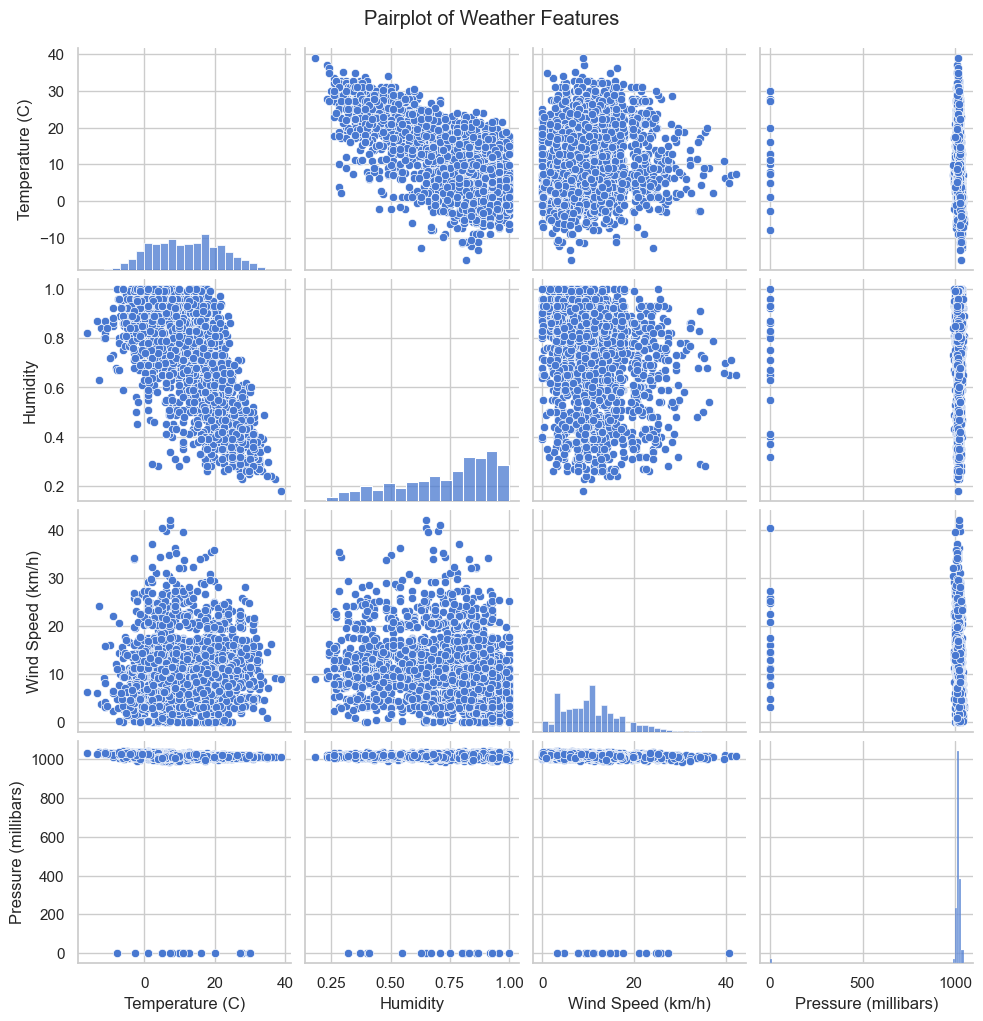

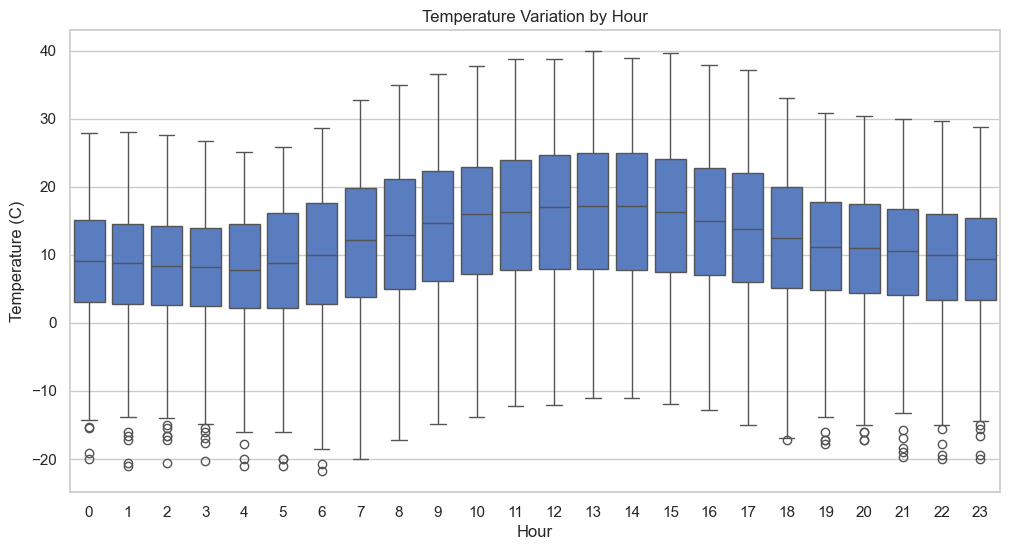

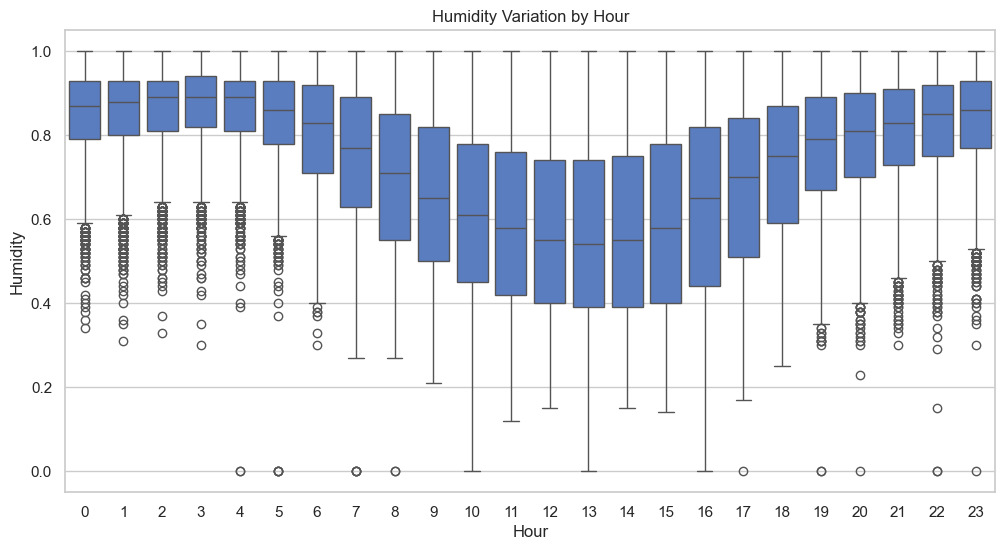

In [5]:
# EDA Analysis with Plots
sns.set(style="whitegrid", palette="muted")

# Temperature distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Temperature (C)'], bins=50, kde=True)
plt.title("Temperature Distribution")
plt.show()

# Apparent Temperature distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Apparent Temperature (C)'], bins=50, kde=True, color='orange')
plt.title("Apparent Temperature Distribution")
plt.show()

sns.jointplot(data=df,x="Temperature (C)",y="Apparent Temperature (C)",kind="hex",color="blue",height=8)
plt.suptitle("Jointplot: Temp vs Apparent Temp", fontsize=14, fontweight='bold', y=1.02)
plt.show()


# Humidity distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Humidity'], bins=50, kde=True, color='green')
plt.title("Humidity Distribution")
plt.show()

# Wind Speed distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Wind Speed (km/h)'], bins=50, kde=True, color='purple')
plt.title("Wind Speed Distribution")
plt.show()

# Pressure distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Pressure (millibars)'], bins=50, kde=True, color='red')
plt.title("Pressure Distribution")
plt.show()

# Temperature vs Humidity scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x="Temperature (C)", y="Humidity", data=df, alpha=0.3)
plt.title("Temperature vs Humidity")
plt.show()

# Temperature vs Pressure scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x="Temperature (C)", y="Pressure (millibars)", data=df, alpha=0.3, color="brown")
plt.title("Temperature vs Pressure")
plt.show()

# Wind Speed vs Visibility scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x="Wind Speed (km/h)", y="Visibility (km)", data=df, alpha=0.3, color="teal")
plt.title("Wind Speed vs Visibility")
plt.show()

# Temperature by Precip Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Precip Type", y="Temperature (C)", data=df)
plt.title("Temperature by Precip Type")
plt.show()

# Humidity by Precip Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Precip Type", y="Humidity", data=df)
plt.title("Humidity by Precip Type")
plt.show()

# Violin Plot: Wind Speed by Wind Category
plt.figure(figsize=(8,5))
sns.violinplot(x="Wind_Category", y="Wind Speed (km/h)", data=df)
plt.title("Wind Speed Distribution by Category")
plt.show()

# Hourly Temperature trend (lineplot)
plt.figure(figsize=(12,5))
sns.lineplot(x="Hour", y="Temperature (C)", data=df, errorbar=None)
plt.title("Average Temperature by Hour of Day")
plt.show()

# Monthly Temperature trend
# Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract month as timestamp sorted 
df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp()

plt.figure(figsize=(12,5))
sns.lineplot(x="Month", y="Temperature (C)", data=df, errorbar=None)
plt.title("Average Temperature by Month")
plt.show()

# Precip Type
plt.figure(figsize=(6,5))
sns.countplot(x="Precip Type", data=df)
plt.title("Precipitation Type Count")
plt.show()

# Wind Category
plt.figure(figsize=(6,5))
sns.countplot(x="Wind_Category", data=df)
plt.title("Wind Category Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.drop(columns=['Loud Cover']).corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (without Loud Cover)")
plt.show()

# Precip type
plt.figure(figsize=(8,8))
explode = [0.09, 0.05] 
colors = sns.color_palette("pastel")
df['Precip Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,colors=colors,explode=explode,shadow=True,textprops={'fontsize': 12})
plt.title("Precipitation Type Distribution", fontsize=16, fontweight='bold')
plt.legend(labels=df['Precip Type'].map({0: "Rain", 1: "Snow"}).value_counts().index,title="Precip Type",loc="best",fontsize=12)
# plt.ylabel("")
plt.show()



# Pairplot of selected features
sns.pairplot(df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']].sample(2000))
plt.suptitle("Pairplot of Weather Features", y=1.02)
plt.show()

# Temperature across Hours
plt.figure(figsize=(12,6))
sns.boxplot(x="Hour", y="Temperature (C)", data=df)
plt.title("Temperature Variation by Hour")
plt.show()

# Humidity across Hours
plt.figure(figsize=(12,6))
sns.boxplot(x="Hour", y="Humidity", data=df)
plt.title("Humidity Variation by Hour")
plt.show()

In [6]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df_numeric = df[numeric_cols].copy()

# Aggregate values
df_numeric['AvgTemp_per_Hour'] = df.groupby('Hour')['Temperature (C)'].transform('mean')
df_numeric['AvgHumidity_per_Hour'] = df.groupby('Hour')['Humidity'].transform('mean')
df_numeric['AvgWindSpeed_per_Hour'] = df.groupby('Hour')['Wind Speed (km/h)'].transform('mean')
df_numeric['AvgPressure_per_Hour'] = df.groupby('Hour')['Pressure (millibars)'].transform('mean')

df_numeric['AvgTemp_per_Day'] = df.groupby('Date')['Temperature (C)'].transform('mean')
df_numeric['AvgHumidity_per_Day'] = df.groupby('Date')['Humidity'].transform('mean')

# Time Values
df_numeric['WeekOfYear'] = df['Date'].dt.isocalendar().week
df_numeric['Quarter'] = df['Date'].dt.quarter
df_numeric['Month'] = df['Date'].dt.month
df_numeric['DayOfWeek'] = df['Date'].dt.dayofweek

# Ratio
df_numeric['Temp_Apparent_Ratio'] = df['Temperature (C)'] / df['Apparent Temperature (C)'].replace(0, np.nan)
df_numeric['Temp_Diff'] = df['Temperature (C)'] - df['Apparent Temperature (C)']
df_numeric['Wind_Humidity_Impact'] = df['Wind Speed (km/h)'] * df['Humidity']

# Vriables
df_numeric['Temp_std_per_Hour'] = df.groupby('Hour')['Temperature (C)'].transform('std')
df_numeric['Humidity_std_per_Hour'] = df.groupby('Hour')['Humidity'].transform('std')
df_numeric['WindSpeed_std_per_Hour'] = df.groupby('Hour')['Wind Speed (km/h)'].transform('std')

df_numeric['Temp_cv_per_Hour'] = df_numeric['Temp_std_per_Hour'] / df_numeric['AvgTemp_per_Hour'].replace(0, np.nan)
df_numeric['Humidity_cv_per_Hour'] = df_numeric['Humidity_std_per_Hour'] / df_numeric['AvgHumidity_per_Hour'].replace(0, np.nan)

# Statistics
summary_stats = df_numeric.describe().T
summary_stats['median'] = df_numeric.median()
summary_stats['skew'] = df_numeric.skew()
summary_stats['kurtosis'] = df_numeric.kurtosis()
summary_stats['missing_values'] = df_numeric.isnull().sum()

print("\n Summary \n")
print(summary_stats)

# Correlation matrix
correlation_matrix = df_numeric.corr()
print("\n Correlation matrix \n")
print(correlation_matrix)

# Top correlated features with Temperature
top_corr_temp = correlation_matrix['Temperature (C)'].sort_values(ascending=False)
print("\n Top Fetures \n")
print(top_corr_temp.head(10))

# Save numeric dataset
df_numeric.to_csv("./datasets/weather_numeric_features.csv", index=False)
print("\n Dataset saved as: './datasets/weather_numeric_features.csv'")



 Summary 

                            count         mean         std         min  \
Precip Type               96429.0     0.111087    0.314241         0.0   
Temperature (C)           96429.0    11.929692    9.550492  -21.822222   
Apparent Temperature (C)  96429.0    10.851707   10.695743  -27.716667   
Humidity                  96429.0     0.734902    0.195466         0.0   
Wind Speed (km/h)         96429.0     10.81246    6.913345         0.0   
Wind Bearing (degrees)    96429.0   187.497506  107.376423         0.0   
Visibility (km)           96429.0    10.347225    4.192548         0.0   
Loud Cover                96429.0          0.0         0.0         0.0   
Pressure (millibars)      96429.0  1003.232915    116.9843         0.0   
Temp_Diff                 96429.0     1.077984    1.678756   -4.811111   
AvgTemp_per_Hour          96429.0    11.929692    3.013638    7.945476   
AvgHumidity_per_Hour      96429.0     0.734902    0.107803        0.57   
AvgWindSpeed_per_Hour     

In [7]:
eda_text = """
| Key Insights from Weather EDA

> Dataset contains 96,429 records with a wide range of weather conditions.
  Average temperature across records is ~11.93°C, with extremes ranging from -21.82°C to 39.91°C.
  Humidity averages ~73%, while wind speeds average ~10.81 km/h.

1. Temperature Insights
   * Apparent Temperature correlates strongly with Temperature (0.99).
   * AvgTemp_per_Day shows a high correlation (0.92) with Temperature, making daily averages good predictors.
   * Temperature varies significantly by hour and day (Temp_std_per_Hour mean ~8.99°C).

2. Humidity Patterns
   * Average humidity is ~0.73 with a median of 0.78.
   * Humidity negatively correlates with temperature (-0.63).
   * Humidity_cv_per_Hour shows substantial variability (mean ~0.23).

3. Wind Insights
   * Wind speed averages ~10.81 km/h, with peaks up to 63.85 km/h.
   * Strong correlation between wind speed and Wind_Humidity_Impact (0.88).
   * Variability in wind speed is moderate (WindSpeed_std_per_Hour mean ~6.65 km/h).

4. Visibility & Pressure
   * Visibility averages ~10.35 km and correlates moderately with temperature (0.39).
   * Pressure averages ~1003.23 millibars but shows extreme variability (std ~116.98).

5. Temporal Trends
   * Temperature and humidity fluctuate across hours and days.
   * WeekOfYear, Month, and Quarter correlate moderately with temperature patterns (0.15–0.17).
   * DayOfWeek has minimal effect on weather variables.

6. Extreme Weather Events
   * Precipitation occurs in ~11% of records.
   * Precip Type correlates negatively with temperature (-0.56) and visibility (-0.31).
   * Temp_Diff has a moderate positive correlation with precipitation (0.40).

7. Correlation Highlights with Temperature
   * Apparent Temperature (0.99), AvgTemp_per_Day (0.92), and Visibility (0.39) are top correlates.
   * Humidity (-0.63) and Temp_Diff (-0.72) are negatively correlated with temperature.
   * Temp_std_per_Hour and Humidity_std_per_Hour show moderate correlations (~0.30).

Key Takeaways:
1. Temperature is strongly predicted by daily and apparent temperature, with humidity and visibility as secondary factors.
2. Humidity patterns inversely follow temperature trends, with substantial variability by hour.
3. Wind speed variability and humidity interactions significantly influence weather perception.
4. Precipitation impacts visibility and temperature differences, indicating weather event severity.
5. Temporal features like month and week influence temperature patterns, useful for seasonal modeling.
"""
print(eda_text)



| Key Insights from Weather EDA

> Dataset contains 96,429 records with a wide range of weather conditions.
  Average temperature across records is ~11.93°C, with extremes ranging from -21.82°C to 39.91°C.
  Humidity averages ~73%, while wind speeds average ~10.81 km/h.

1. Temperature Insights
   * Apparent Temperature correlates strongly with Temperature (0.99).
   * AvgTemp_per_Day shows a high correlation (0.92) with Temperature, making daily averages good predictors.
   * Temperature varies significantly by hour and day (Temp_std_per_Hour mean ~8.99°C).

2. Humidity Patterns
   * Average humidity is ~0.73 with a median of 0.78.
   * Humidity negatively correlates with temperature (-0.63).
   * Humidity_cv_per_Hour shows substantial variability (mean ~0.23).

3. Wind Insights
   * Wind speed averages ~10.81 km/h, with peaks up to 63.85 km/h.
   * Strong correlation between wind speed and Wind_Humidity_Impact (0.88).
   * Variability in wind speed is moderate (WindSpeed_std_per_Hou

In [8]:
weather_recommendations = """
| Weather Data Recommendations

1. Monitor Critical Weather Parameters:
   - Keep a close watch on Temperature, Apparent Temperature, and Humidity — these factors tend to change the most and affect weather significantly.
   - Use real-time weather sensors to improve accuracy in forecasts.
   - Track Temp_Diff and Temp_Apparent_Ratio to better understand sudden weather changes.
   - Regularly calibrate weather instruments for reliable readings.

2. Seasonal Planning:
   - Be ready for peak temperatures in summer months, especially in June and July.
   - Expect higher humidity during monsoon months and use AvgHumidity_per_Day trends to plan ahead.
   - Use monthly and quarterly weather trends to prepare for the long term.
   - Create alerts for sudden temperature drops or spikes, especially during seasonal changes.

3. Safety & Public Awareness:
   - Issue timely advisories during extreme temperature or high wind events.
   - Raise public awareness about heat index, humidity impacts, and weather safety tips.
   - Monitor low visibility days (often linked with temperature and humidity changes) to issue transport safety alerts.
   - Make sure storm warning systems are active in areas with high precipitation.

4. Infrastructure & Environment:
   - Adapt urban infrastructure to cope with weather changes (cooling shelters, improved storm drainage, wind protection structures).
   - Keep track of Pressure (in millibars) to predict storms and take preemptive measures.
   - Promote green building practices to reduce temperature extremes and humidity effects.
   - Use visibility and wind speed data to improve safety for airports, roads, and marine transport.

5. Data-Driven Forecasting:
   - Use AvgTemp_per_Hour, AvgHumidity_per_Hour, and AvgPressure_per_Hour to create more accurate predictions.
   - Develop local forecasts using hourly, daily, and monthly averages.
   - Study correlations between temperature and other factors to improve accuracy.
   - Use historical patterns to strengthen seasonal planning and climate adaptation.

6. Environmental Impact:
   - Focus on places with high Wind_Humidity_Impact and Temp_std_per_Hour to spot environmental risks.
   - Track extreme weather conditions for better climate resilience.
   - Use variability metrics to improve early warning systems.
   - Monitor pollution levels alongside weather changes to support environmental policy.

7. Community & Awareness Actions:
   - Provide public dashboards for weather alerts and forecasts.
   - Educate people on how to read weather reports and stay safe.
   - Work with local agencies to respond quickly to extreme weather events.
   - Encourage community reporting of unusual weather events to improve data accuracy.

8. Key Takeaways:
   - Temperature and Apparent Temperature should always be tracked together.
   - Humidity changes strongly affect comfort and environmental conditions.
   - Seasonal and hourly averages are key for accurate forecasting.
   - Real-time monitoring of wind and visibility is critical for transport safety.
   - Data-driven approaches improve preparedness, safety, and resilience.
"""
print(weather_recommendations)



| Weather Data Recommendations

1. Monitor Critical Weather Parameters:
   - Keep a close watch on Temperature, Apparent Temperature, and Humidity — these factors tend to change the most and affect weather significantly.
   - Use real-time weather sensors to improve accuracy in forecasts.
   - Track Temp_Diff and Temp_Apparent_Ratio to better understand sudden weather changes.
   - Regularly calibrate weather instruments for reliable readings.

2. Seasonal Planning:
   - Be ready for peak temperatures in summer months, especially in June and July.
   - Expect higher humidity during monsoon months and use AvgHumidity_per_Day trends to plan ahead.
   - Use monthly and quarterly weather trends to prepare for the long term.
   - Create alerts for sudden temperature drops or spikes, especially during seasonal changes.

3. Safety & Public Awareness:
   - Issue timely advisories during extreme temperature or high wind events.
   - Raise public awareness about heat index, humidity impacts, an

In [9]:
# Training Model
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


# Features 
features = [
    "Apparent Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)",
    "Wind Bearing (degrees)",
    "Visibility (km)",
    "Pressure (millibars)",
    "Hour",
    "Temp_Diff",
    "Wind_Category",
    "Precip Type"
]

target = "Temperature (C)"

# Drop rows with missing values
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model 
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,           
    min_samples_split=5,    
    min_samples_leaf=2,     
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R² scores:", np.round(cv_scores, 3))
print("R² score avg:", np.round(cv_scores.mean(), 3))

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Model Evaluation:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

# Save model
joblib.dump(model, "./models/weather_temp_model.pkl")
print("\n Model saved './models/weather_temp_model.pkl'")


R² scores: [1.    1.    0.999 1.    1.   ]
R² score avg: 1.0

 Model Evaluation:
MAE: 0.042
MSE: 0.007
R² Score: 1.000

 Model saved './models/weather_temp_model.pkl'


In [10]:
# Load Model
import joblib
import pandas as pd

# Load model
model = joblib.load("./models/weather_temp_model.pkl")

# Example
example_cases = pd.DataFrame([
    {
        "Apparent Temperature (C)": 25.0,
        "Humidity": 0.65,
        "Wind Speed (km/h)": 10.0,
        "Wind Bearing (degrees)": 180.0,
        "Visibility (km)": 10.0,
        "Pressure (millibars)": 1012.0,
        "Hour": 14,
        "Temp_Diff": 1.5,
        "Wind_Category": 1,   
        "Precip Type": 0      
    },
    {
        "Apparent Temperature (C)": -2.0,
        "Humidity": 0.85,
        "Wind Speed (km/h)": 20.0,
        "Wind Bearing (degrees)": 250.0,
        "Visibility (km)": 5.0,
        "Pressure (millibars)": 1005.0,
        "Hour": 3,
        "Temp_Diff": -1.0,
        "Wind_Category": 2,   
        "Precip Type": 1      
    }
])

predictions = model.predict(example_cases)

# Results
for i, pred in enumerate(predictions, 1):
    print(f"Case {i} predicted Temperature (C): {pred:.2f}")

Case 1 predicted Temperature (C): 25.00
Case 2 predicted Temperature (C): -0.10
